##  PHASE 1 DATA LOADING

In [2]:

# PHASE 1 — SETUP

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [33]:
!unzip "/content/drive/MyDrive/archive.zip" -d /content/data

Archive:  /content/drive/MyDrive/archive.zip
replace /content/data/stock_prices_daily.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [35]:
import pandas as pd

file_path = "/content/data/stock_prices_daily.csv"

df = pd.read_csv(file_path)

print(df.head())
print(df.shape)
print(df.columns)

                        Date Ticker Company_Name      Sector  \
0  2020-01-03 00:00:00-05:00   AAPL   Apple Inc.  Technology   
1  2020-01-06 00:00:00-05:00   AAPL   Apple Inc.  Technology   
2  2020-01-07 00:00:00-05:00   AAPL   Apple Inc.  Technology   
3  2020-01-08 00:00:00-05:00   AAPL   Apple Inc.  Technology   
4  2020-01-09 00:00:00-05:00   AAPL   Apple Inc.  Technology   

               Industry       Open       High        Low      Close  \
0  Consumer Electronics  71.629153  72.455966  71.472469  71.696648   
1  Consumer Electronics  70.819208  72.306506  70.568510  72.267937   
2  Consumer Electronics  72.277571  72.533087  71.708687  71.928047   
3  Consumer Electronics  71.631559  73.386431  71.631559  73.085114   
4  Consumer Electronics  74.061360  74.830322  73.810669  74.637482   

   Adj_Close     Volume  
0  71.696648  146322800  
1  72.267937  118387200  
2  71.928047  108872000  
3  73.085114  132079200  
4  74.637482  170108400  
(184138, 11)
Index(['Date', 'Tic

In [36]:
df['Ticker'].unique()

array(['AAPL', 'ABBV', 'ABT', 'ADBE', 'AIG', 'AMAT', 'AMD', 'AMGN',
       'AMZN', 'APD', 'AVGO', 'AXP', 'BA', 'BAC', 'BIIB', 'BLK', 'BMY',
       'BRK-B', 'C', 'CARR', 'CAT', 'CB', 'CI', 'CL', 'CMCSA', 'CME',
       'COF', 'COP', 'COST', 'CRM', 'CSCO', 'CSX', 'CVS', 'CVX', 'DD',
       'DE', 'DHR', 'DIS', 'DOW', 'ECL', 'EL', 'ELV', 'EMR', 'EOG', 'ETN',
       'FCX', 'FDX', 'GD', 'GE', 'GILD', 'GOOGL', 'GS', 'HAL', 'HD',
       'HON', 'IBM', 'INTC', 'INTU', 'ISRG', 'ITW', 'JNJ', 'JPM', 'KO',
       'LIN', 'LLY', 'LMT', 'LOW', 'MA', 'MCD', 'META', 'MMM', 'MPC',
       'MRK', 'MS', 'MSFT', 'NEM', 'NFLX', 'NKE', 'NOC', 'NOW', 'NSC',
       'NUE', 'NVDA', 'ORCL', 'OXY', 'PEP', 'PFE', 'PG', 'PM', 'PNC',
       'PSX', 'QCOM', 'REGN', 'RTX', 'SBUX', 'SCHW', 'SHW', 'SLB', 'SPGI',
       'T', 'TFC', 'TGT', 'TJX', 'TMO', 'TSLA', 'TXN', 'UNH', 'UNP',
       'UPS', 'USB', 'V', 'VLO', 'VMC', 'VRTX', 'VZ', 'WFC', 'WM', 'WMT',
       'XOM', 'ZTS'], dtype=object)

In [38]:
# Filter ONE stock
df = df[df['Ticker'] == 'AAPL']
df = df.reset_index(drop=True)

In [39]:
#Sort by date
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

/tmp/ipykernel_13860/2190876542.py:2: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date'] = pd.to_datetime(df['Date'])


In [40]:
#Keep only useful columns
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
print(df.head())

        Open       High        Low      Close     Volume
0  71.629153  72.455966  71.472469  71.696648  146322800
1  70.819208  72.306506  70.568510  72.267937  118387200
2  72.277571  72.533087  71.708687  71.928047  108872000
3  71.631559  73.386431  71.631559  73.085114  132079200
4  74.061360  74.830322  73.810669  74.637482  170108400


In [42]:
#Quick sanity check
print(df.shape)
print(df.columns)

(1535, 5)
Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


In [43]:
#Check missing values
print(df.isnull().sum())

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


## PHASE 2 — Exploratory Data Understanding

In [46]:
df.describe() #Statistical summary

,Open,High,Low,Close,Volume
count,1535.000000,1535.000000,1535.000000,1535.000000,1.535000e+03
mean,166.467717,168.328732,164.759373,166.623952,8.394138e+07
std,50.853693,51.205393,50.534958,50.888215,5.110307e+07
min,55.110038,55.211520,51.372085,54.213604,1.791060e+07
25%,132.164972,133.537255,130.456985,132.430077,5.041420e+07
50%,164.710996,166.644986,163.271276,164.652115,6.972110e+07
75%,201.337313,203.472170,199.403206,201.018288,9.922350e+07
max,285.932471,288.350192,283.035157,285.922455,4.265100e+08


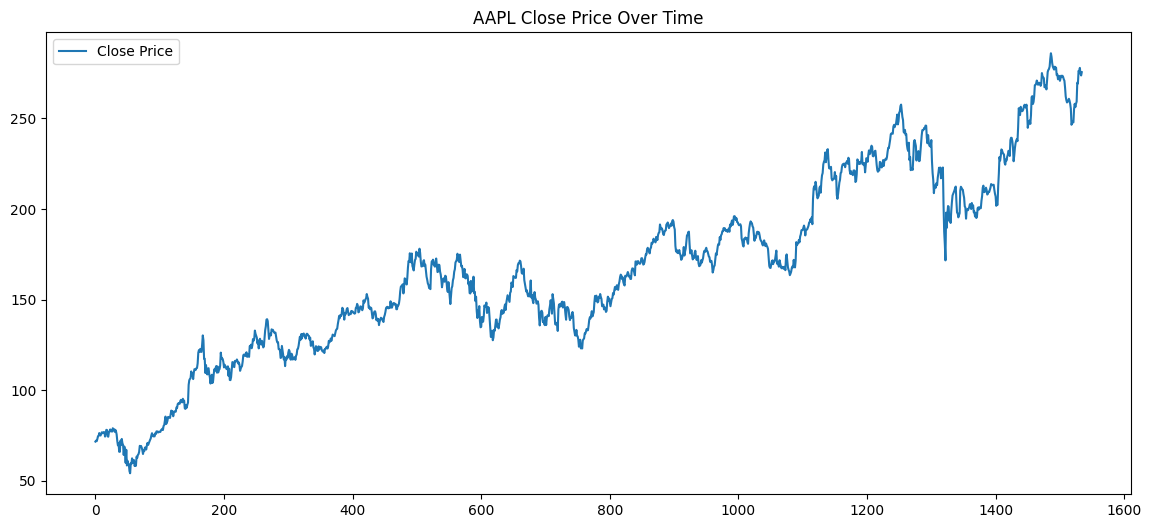

In [47]:
# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close Price')
plt.title("AAPL Close Price Over Time")
plt.legend()
plt.show()

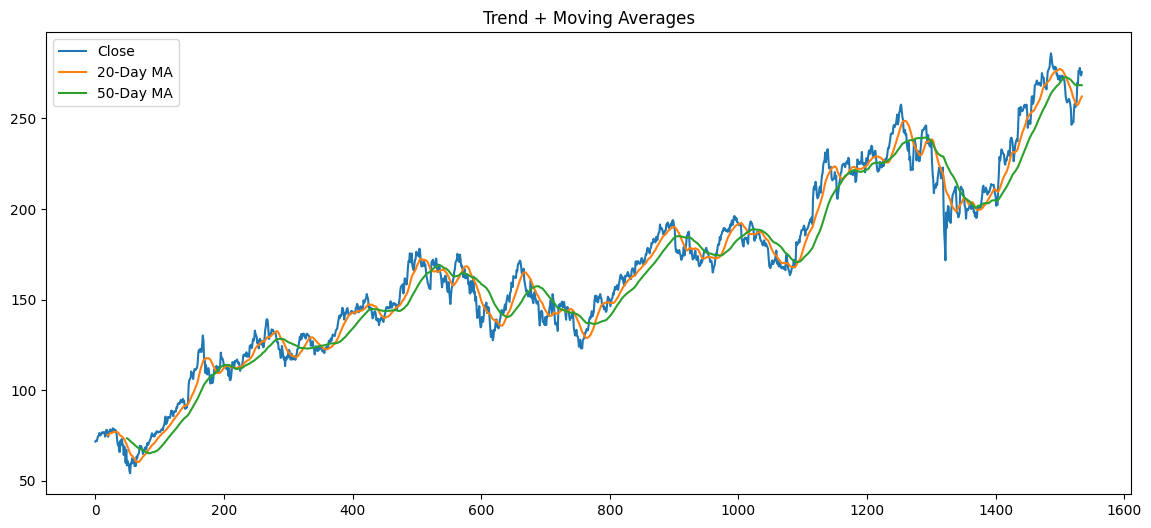

In [48]:
# Moving Average
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close')
plt.plot(df['MA20'], label='20-Day MA')
plt.plot(df['MA50'], label='50-Day MA')
plt.legend()
plt.title("Trend + Moving Averages")
plt.show()

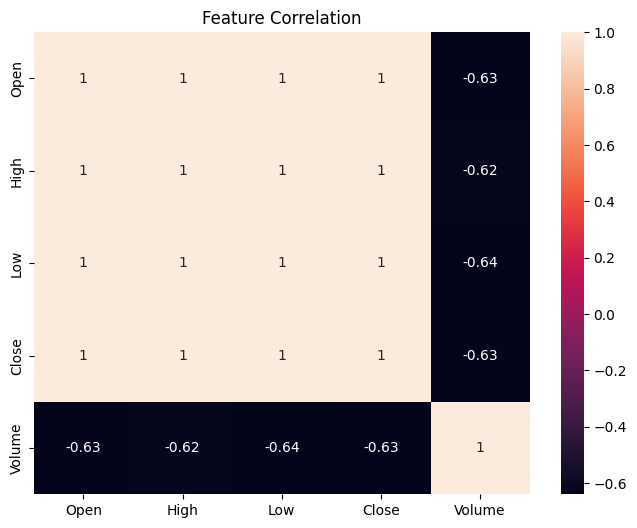

In [50]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df[['Open','High','Low','Close','Volume']].corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

### Check other features behavior

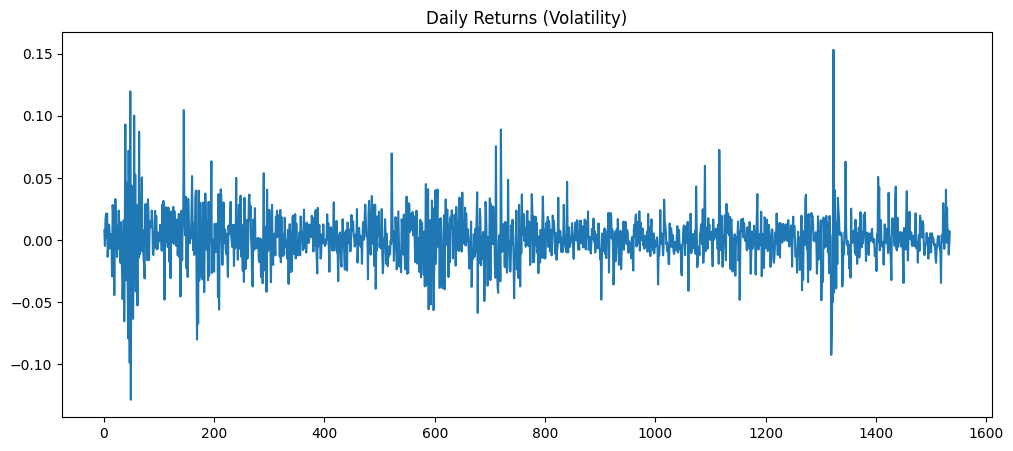

In [49]:
df['Return'] = df['Close'].pct_change()

plt.figure(figsize=(12,5))
plt.plot(df['Return'])
plt.title("Daily Returns (Volatility)")
plt.show()

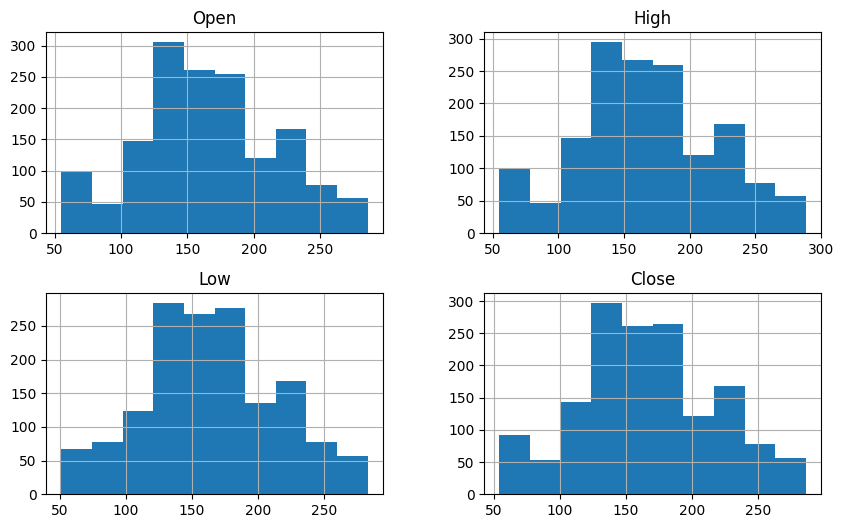

In [51]:
# Distribution check
df[['Open','High','Low','Close']].hist(figsize=(10,6))
plt.show()

## PHASE 3 — DATA PREPROCESSING

In [52]:
#Select features

df_model = df[['Open','High','Low','Close','Volume']].copy()

In [53]:
# TRAIN/VAL/TEST SPLIT
train_size = int(len(df_model) * 0.7)
val_size = int(len(df_model) * 0.2)
test_size = len(df_model) - train_size - val_size

train_data = df_model[:train_size]
val_data = df_model[train_size:train_size + val_size]
test_data = df_model[train_size + val_size:]

In [54]:
#Scale data

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

## Create sequences
What we are doing:

We convert:

Day 1 → Day 50  => predict Day 51 Close
Day 2 → Day 51  => predict Day 52 Close

In [55]:
def create_sequences(data, seq_length):
    X, y = [], []

    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i, 3])  # index 3 = Close

    return np.array(X), np.array(y)

In [56]:
# CREATE SEQUENCES

SEQ_LEN = 50
# Now create datasets:
X_train, y_train = create_sequences(train_scaled, SEQ_LEN)
X_val, y_val = create_sequences(val_scaled, SEQ_LEN)
X_test, y_test = create_sequences(test_scaled, SEQ_LEN)

In [57]:
#Check shapes

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (1024, 50, 5)
X_val: (257, 50, 5)
X_test: (104, 50, 5)


## PHASE 4 — MODEL BUILDING (RNN, GRU, LSTM)

In [58]:
#INPUT SHAPE
timesteps = X_train.shape[1]
features = X_train.shape[2]

###MODEL 1 — Simple RNN (Baseline)


In [59]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

rnn_model = Sequential([
    SimpleRNN(64, return_sequences=False, input_shape=(timesteps, features)),
    Dense(32, activation='relu'),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## 🟡 MODEL 2 — GRU


In [61]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([
    GRU(64, return_sequences=False, input_shape=(timesteps, features)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

##  MODEL 3 — LSTM


In [62]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(timesteps, features)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

## PHASE 5 — TRAINING MODELS

Now we train RNN, GRU, and LSTM on the same data so the comparison is fair.

In [63]:
EPOCHS = 10
BATCH_SIZE = 32

In [64]:
#TRAIN SIMPLE RNN
rnn_history = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=False   # IMPORTANT for time series
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0077 - mae: 0.0660 - val_loss: 0.0853 - val_mae: 0.2775
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0243 - mae: 0.1179 - val_loss: 0.0288 - val_mae: 0.1462
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0176 - mae: 0.1140 - val_loss: 0.0065 - val_mae: 0.0631
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0078 - mae: 0.0717 - val_loss: 0.0057 - val_mae: 0.0631
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0050 - mae: 0.0566 - val_loss: 0.0112 - val_mae: 0.0975
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0028 - mae: 0.0372 - val_loss: 0.0069 - val_mae: 0.0708
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0014 - mae: 0.0298 - val_loss: 0.0048 - val_mae: 0.0582
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0011 - mae: 0.0256 - val_loss: 0.0072 - val_mae: 0.0751
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.5463e-04

In [65]:
history_gru = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=False   # IMPORTANT for time series
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0222 - mae: 0.1253 - val_loss: 0.0029 - val_mae: 0.0423
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0120 - mae: 0.0824 - val_loss: 0.0096 - val_mae: 0.0895
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0017 - mae: 0.0326 - val_loss: 0.0043 - val_mae: 0.0561
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0011 - mae: 0.0261 - val_loss: 0.0030 - val_mae: 0.0455
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.0673e-04 - mae: 0.0207 - val_loss: 0.0024 - val_mae: 0.0398
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.8448e-04 - mae: 0.0205 - val_loss: 0.0021 - val_mae: 0.0364
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.7472e-04 - mae: 0.0202 - val_loss: 0.0019 - val_mae: 0.0347
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.7206e-04 - mae: 0.0202 - val_loss: 0.0018 - val_mae: 0.0337
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - los

In [66]:
#TRAIN LSTM
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=False   # IMPORTANT for time series
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0073 - mae: 0.0720 - val_loss: 0.0046 - val_mae: 0.0543
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0098 - mae: 0.0838 - val_loss: 0.0030 - val_mae: 0.0424
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0037 - mae: 0.0490 - val_loss: 0.0045 - val_mae: 0.0551
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0012 - mae: 0.0284 - val_loss: 0.0049 - val_mae: 0.0590
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0010 - mae: 0.0264 - val_loss: 0.0041 - val_mae: 0.0522
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0012 - mae: 0.0274 - val_loss: 0.0034 - val_mae: 0.0468
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0013 - mae: 0.0290 - val_loss: 0.0031 - val_mae: 0.0443
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0015 - mae: 0.0306 - val_loss: 0.0029 - val_mae: 0.0423
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0014 - mae

## PHASE 6 — MODEL EVALUATION & COMPARISON

In [68]:
#Predict with all models
rnn_pred = rnn_model.predict(X_test, verbose=0)
gru_pred = gru_model.predict(X_test, verbose=0)
lstm_pred = lstm_model.predict(X_test, verbose=0)

In [69]:
# INVERSE TRANSFORMATION
import numpy as np

def inverse_close(pred, true, df_model, scaler):

    n_features = df_model.shape[1]
    close_idx = df_model.columns.get_loc('Close')

    def inverse(x):
        dummy = np.zeros((len(x), n_features))
        dummy[:, close_idx] = x.flatten()
        return scaler.inverse_transform(dummy)[:, close_idx]

    return inverse(true), inverse(pred)

In [70]:
rnn_true, rnn_pred_inv = inverse_close(rnn_pred, y_test, df_model, scaler)
gru_true, gru_pred_inv = inverse_close(gru_pred, y_test, df_model, scaler)
lstm_true, lstm_pred_inv = inverse_close(lstm_pred, y_test, df_model, scaler)

In [71]:
# REAL METRICS
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse


results = []

for name, true, pred in [
    ("RNN", rnn_true, rnn_pred_inv),
    ("GRU", gru_true, gru_pred_inv),
    ("LSTM", lstm_true, lstm_pred_inv)
]:
    mae, rmse = evaluate(true, pred)
    results.append([name, mae, rmse])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE"])
results_df

,Model,MAE,RMSE
0,RNN,27.254181,28.002142
1,GRU,11.531270,12.354025
2,LSTM,15.320741,16.351496


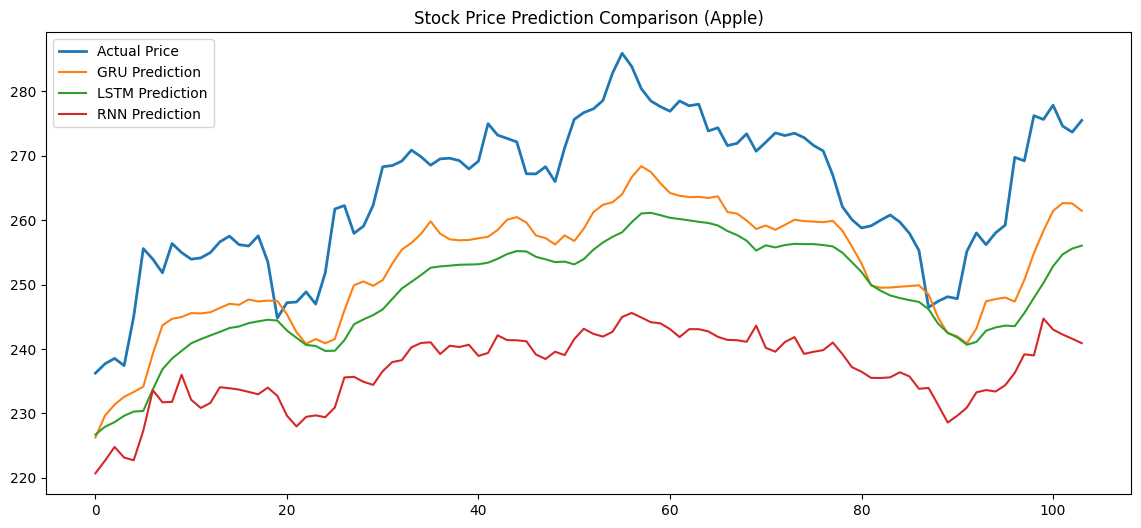

In [72]:
# VISUAL COMPARISON
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(gru_true[:200], label="Actual Price", linewidth=2)
plt.plot(gru_pred_inv[:200], label="GRU Prediction")
plt.plot(lstm_pred_inv[:200], label="LSTM Prediction")
plt.plot(rnn_pred_inv[:200], label="RNN Prediction")

plt.title("Stock Price Prediction Comparison (Apple)")
plt.legend()
plt.show()

In [73]:
# BEST MODEL SELECTION
best_model = results_df.loc[results_df["RMSE"].idxmin()]
print("Best Model:")
print(best_model)

Best Model:
Model          GRU
MAE       11.53127
RMSE     12.354025
Name: 1, dtype: object


In [75]:
# SAVE BEST MODEL (GRU)
gru_model.save("/content/drive/MyDrive/gru_best_stock_model.keras")

In [76]:
#SAVE SCALER
import joblib

joblib.dump(scaler, "/content/drive/MyDrive/scaler.pkl")

['/content/drive/MyDrive/scaler.pkl']

## PHASE 7 — FUTURE FORECASTING + TRADING LOGIC

In [77]:
# LOAD SAVED MODEL + SCALER
from tensorflow.keras.models import load_model
import joblib

gru_model = load_model("/content/drive/MyDrive/gru_best_stock_model.keras")
scaler = joblib.load("/content/drive/MyDrive/scaler.pkl")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 11 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [78]:
seq_length = X_train.shape[1]

last_sequence = X_test[-1]
current_input = last_sequence.reshape(1, seq_length, X_test.shape[2])

In [79]:
# PREDICT NEXT 7 DAYS
import numpy as np

future_predictions = []

input_seq = current_input.copy()

n_features = df_model.shape[1]
close_idx = df_model.columns.get_loc("Close")

for _ in range(7):

    pred = gru_model.predict(input_seq, verbose=0)[0][0]
    future_predictions.append(pred)

    # shift window
    new_seq = np.roll(input_seq[0], -1, axis=0)

    # update only Close column
    new_seq[-1, :] = 0
    new_seq[-1, close_idx] = pred

    input_seq = new_seq.reshape(1, seq_length, n_features)

In [80]:
# INVERSE SCALE (REAL STOCK PRICE)
future_dummy = np.zeros((len(future_predictions), n_features))
future_dummy[:, close_idx] = future_predictions

future_prices = scaler.inverse_transform(future_dummy)[:, close_idx]

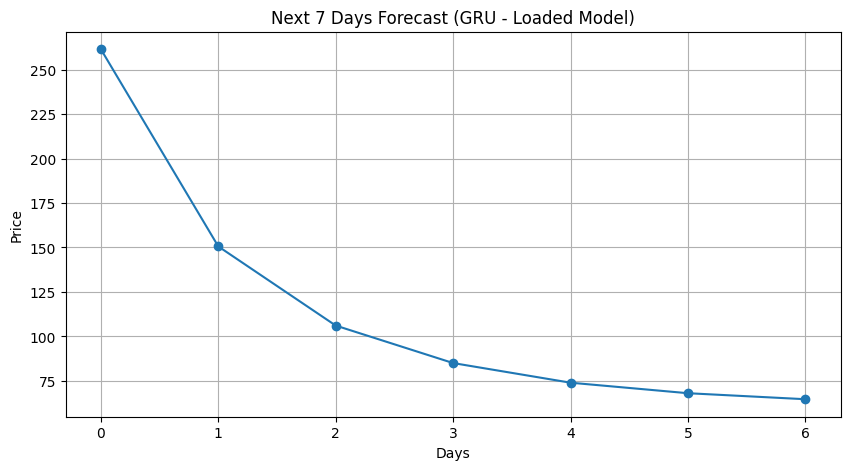

In [81]:
# VISUALIZE FUTURE PREDICTION
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(future_prices, marker='o')
plt.title("Next 7 Days Forecast (GRU - Loaded Model)")
plt.xlabel("Days")
plt.ylabel("Price")
plt.grid()
plt.show()

In [82]:
# PRINT RESULTS
for i, price in enumerate(future_prices):
    print(f"Day {i+1}: {price:.2f}")

Day 1: 261.45
Day 2: 150.58
Day 3: 106.09
Day 4: 85.01
Day 5: 73.97
Day 6: 68.06
Day 7: 64.69


In [83]:
gru_pred = gru_model.predict(X_test, verbose=0)

In [84]:
import numpy as np

n_features = df_model.shape[1]
close_idx = df_model.columns.get_loc("Close")

def inverse(pred, true):
    dummy_pred = np.zeros((len(pred), n_features))
    dummy_true = np.zeros((len(true), n_features))

    dummy_pred[:, close_idx] = pred.flatten()
    dummy_true[:, close_idx] = true.flatten()

    pred_inv = scaler.inverse_transform(dummy_pred)[:, close_idx]
    true_inv = scaler.inverse_transform(dummy_true)[:, close_idx]

    return true_inv, pred_inv


actual, predicted = inverse(gru_pred, y_test)

In [85]:
# SAMPLE COMPARISON (FIRST 50)
for i in range(50):
    print(f"Day {i+1}: Actual = {actual[i]:.2f} | Predicted = {predicted[i]:.2f}")

Day 1: Actual = 236.25 | Predicted = 226.26
Day 2: Actual = 237.70 | Predicted = 229.66
Day 3: Actual = 238.54 | Predicted = 231.35
Day 4: Actual = 237.43 | Predicted = 232.57
Day 5: Actual = 245.03 | Predicted = 233.32
Day 6: Actual = 255.59 | Predicted = 234.16
Day 7: Actual = 253.95 | Predicted = 239.28
Day 8: Actual = 251.83 | Predicted = 243.67
Day 9: Actual = 256.38 | Predicted = 244.69
Day 10: Actual = 254.97 | Predicted = 244.97
Day 11: Actual = 253.95 | Predicted = 245.58
Day 12: Actual = 254.15 | Predicted = 245.52
Day 13: Actual = 254.96 | Predicted = 245.70
Day 14: Actual = 256.64 | Predicted = 246.38
Day 15: Actual = 257.53 | Predicted = 247.02
Day 16: Actual = 256.20 | Predicted = 246.86
Day 17: Actual = 255.99 | Predicted = 247.69
Day 18: Actual = 257.57 | Predicted = 247.38
Day 19: Actual = 253.56 | Predicted = 247.52
Day 20: Actual = 244.80 | Predicted = 247.46
Day 21: Actual = 247.19 | Predicted = 245.38
Day 22: Actual = 247.30 | Predicted = 242.61
Day 23: Actual = 24